1. Importación de librerías

In [1]:
import os
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, optimizers
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau
from sklearn.metrics import (confusion_matrix, classification_report, accuracy_score,
                             precision_score, recall_score, f1_score, roc_auc_score)
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Ignorar warnings para limpieza del output
import warnings
warnings.filterwarnings('ignore')

print(f"TensorFlow Version: {tf.__version__}")
print(f"NumPy Version: {np.__version__}")

TensorFlow Version: 2.19.0
NumPy Version: 2.0.2


2. Configuración del entorno

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Semillas para reproducibilidad
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Configuración de GPU
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
        print(f"✅ GPU detectada: {len(gpus)} disponible(s)")
    except RuntimeError as e:
        print(e)
else:
    print("⚠️ No se detectó GPU. El entrenamiento será lento.")

# Parámetros Globales
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
CHANNELS = 3
INPUT_SHAPE = IMG_SIZE + (CHANNELS,)
NUM_EPOCHS_HEAD = 5    # Épocas fase 1 (cabeza)
NUM_EPOCHS_FINE = 15   # Épocas fase 2 (fine-tuning)

BASE_DIR = "/content/drive/MyDrive/Dataset" 
TRAIN_DIR = os.path.join(BASE_DIR, "Train")
VAL_DIR   = os.path.join(BASE_DIR, "Validation")
TEST_DIR  = os.path.join(BASE_DIR, "Test")
MODELS_DIR = "/content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2"
os.makedirs(MODELS_DIR, exist_ok=True)
BEST_MODEL_PATH = os.path.join(MODELS_DIR, "banano_MobileNetV2_best_scientific.keras")

✅ GPU detectada: 1 disponible(s)


3. Carga y exploración del dataset

Found 3500 files belonging to 7 classes.
Found 350 files belonging to 7 classes.
Found 350 files belonging to 7 classes.

🏷️ Clases detectadas (7): ['apto', 'cascara_partida', 'cicatriz_golpe', 'corte_cuchareta', 'mal_formaciones', 'marca_madurez', 'plaga_enfermedades']


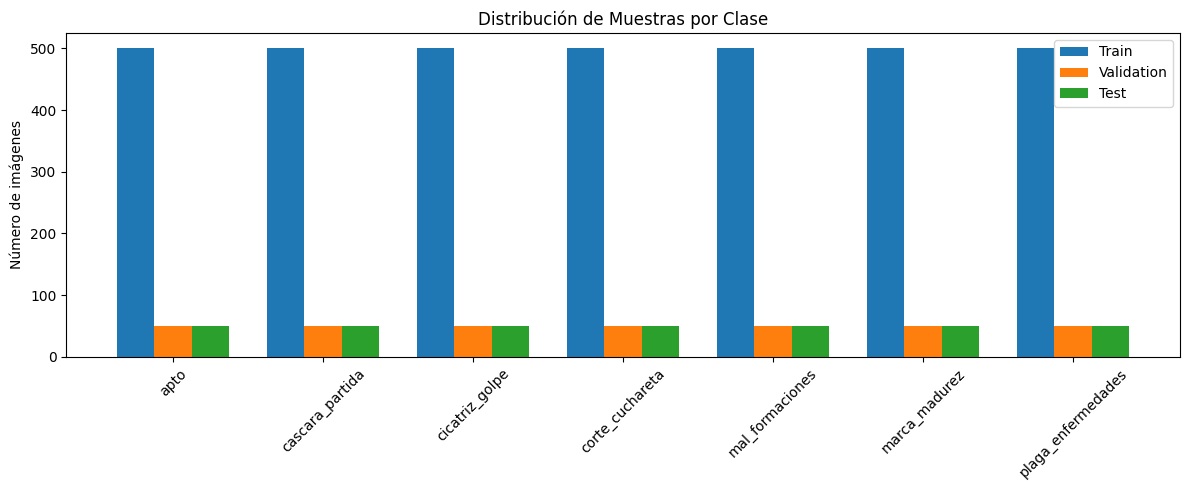

,Clase,Train Samples,Validation Samples,Test Samples
0,apto,500,50,50
1,cascara_partida,500,50,50
2,cicatriz_golpe,500,50,50
3,corte_cuchareta,500,50,50
4,mal_formaciones,500,50,50
5,marca_madurez,500,50,50
6,plaga_enfermedades,500,50,50


In [4]:
# Carga de datasets usando image_dataset_from_directory
train_ds = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=True,
    seed=SEED
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    TEST_DIR,
    labels='inferred',
    label_mode='categorical',
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    shuffle=False,
    seed=SEED
)

class_names = train_ds.class_names
num_classes = len(class_names)

print(f"\n🏷️ Clases detectadas ({num_classes}): {class_names}")

# Tabla de Support (Conteo de muestras)
def count_samples(directory, class_names):
    counts = []
    for cls in class_names:
        path = os.path.join(directory, cls)
        if os.path.exists(path):
            counts.append(len(os.listdir(path)))
        else:
            counts.append(0)
    return counts

train_counts = count_samples(TRAIN_DIR, class_names)
val_counts = count_samples(VAL_DIR, class_names)
test_counts = count_samples(TEST_DIR, class_names)

df_support = pd.DataFrame({
    'Clase': class_names,
    'Train Samples': train_counts,
    'Validation Samples': val_counts,
    'Test Samples': test_counts
})

# Gráfico de distribución
plt.figure(figsize=(12, 5))
x = np.arange(len(class_names))
width = 0.25
plt.bar(x - width, train_counts, width, label='Train', color='#1f77b4')
plt.bar(x, val_counts, width, label='Validation', color='#ff7f0e')
plt.bar(x + width, test_counts, width, label='Test', color='#2ca02c')
plt.xticks(x, class_names, rotation=45)
plt.ylabel('Número de imágenes')
plt.title('Distribución de Muestras por Clase')
plt.legend()
plt.tight_layout()
plt.show()

display(df_support)

TABLA 1: DISTRIBUCIÓN POR CLASES DETALLADA

In [5]:
# ==========================================
# TABLA 1: DISTRIBUCIÓN POR CLASES DETALLADA
# ==========================================

# Calcular totales por clase
total_per_class = [t + v + te for t, v, te in zip(train_counts, val_counts, test_counts)]
total_dataset = sum(total_per_class)

# Calcular porcentajes
percentages = [f"{(count/total_dataset)*100:.2f}%" for count in total_per_class]

df_distribution = pd.DataFrame({
    'Clase (Etiqueta)': class_names,
    'Entrenamiento (Train)': train_counts,
    'Validación (Val)': val_counts,
    'Prueba (Test)': test_counts,
    'Total Muestras': total_per_class,
    'Distribución (%)': percentages
})

# Añadir fila de totales
row_total = pd.DataFrame({
    'Clase (Etiqueta)': ['TOTAL'],
    'Entrenamiento (Train)': [sum(train_counts)],
    'Validación (Val)': [sum(val_counts)],
    'Prueba (Test)': [sum(test_counts)],
    'Total Muestras': [total_dataset],
    'Distribución (%)': ['100%']
})

df_distribution = pd.concat([df_distribution, row_total], ignore_index=True)

print("\n📋 Tabla 1: Distribución del Dataset por Clases")
display(df_distribution)


📋 Tabla 1: Distribución del Dataset por Clases


,Clase (Etiqueta),Entrenamiento (Train),Validación (Val),Prueba (Test),Total Muestras,Distribución (%)
0,apto,500,50,50,600,14.29%
1,cascara_partida,500,50,50,600,14.29%
2,cicatriz_golpe,500,50,50,600,14.29%
3,corte_cuchareta,500,50,50,600,14.29%
4,mal_formaciones,500,50,50,600,14.29%
5,marca_madurez,500,50,50,600,14.29%
6,plaga_enfermedades,500,50,50,600,14.29%
7,TOTAL,3500,350,350,4200,100%


4. Preprocesamiento de datos

In [ ]:
# Optimización de carga (Prefetching)
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.cache().prefetch(buffer_size=AUTOTUNE)

# Capa de Data Augmentation dentro del modelo 
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomTranslation(0.1, 0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
], name="Data_Augmentation")

print("✅ Pipeline de datos configurado.")

✅ Pipeline de datos configurado.


In [7]:
# ==================================================
# TABLA 2: TÉCNICAS DE PREPROCESAMIENTO APLICADAS
# ==================================================
preprocessing_data = [
    ["Redimensionamiento (Resize)", f"{IMG_SIZE[0]}x{IMG_SIZE[1]} píxeles", "Estandarización de entrada"],
    ["Espacio de Color", "RGB (3 canales)", "Formato estándar de imagen"],
    ["Normalización", "preprocess_input (MobileNetV2)", "Escala pixeles a rango [-1,1]"],
    ["Batching", f"{BATCH_SIZE} imágenes por lote", "Optimización de memoria GPU"],
    ["Prefetching", "Autotune (Buffer dinámico)", "Carga asíncrona CPU-GPU"],
    ["Caching", "Memoria/Disco", "Evita recargar imágenes en cada época"]
]

df_preprocessing = pd.DataFrame(preprocessing_data, columns=["Técnica", "Configuración", "Justificación"])

print("\n🛠️ Tabla 2: Técnicas de Preprocesamiento")
display(df_preprocessing)


# ==================================================
# TABLA 3: TÉCNICAS DE AUMENTO DE DATOS (DATA AUGMENTATION)
# ==================================================
augmentation_data = [
    ["Random Flip", "Horizontal", "Simula espejo (izquierda/derecha)"],
    ["Random Rotation", "Factor 0.1 (±10%)", "Simula variaciones en el ángulo de captura"],
    ["Random Zoom", "Factor 0.1 (±10%)", "Simula distancia de la cámara"],
    ["Random Translation", "Height/Width 0.1", "Simula desplazamiento del objeto en el encuadre"],
    ["Random Contrast", "Factor 0.1", "Variabilidad en condiciones de iluminación"],
    ["Random Brightness", "Factor 0.1", "Variabilidad en exposición de luz"]
]

df_augmentation = pd.DataFrame(augmentation_data, columns=["Transformación", "Parámetros", "Objetivo"])

print("\n🔄 Tabla 3: Estrategia de Data Augmentation")
display(df_augmentation)


🛠️ Tabla 2: Técnicas de Preprocesamiento


,Técnica,Configuración,Justificación
0,Redimensionamiento (Resize),224x224 píxeles,Estandarización de entrada
1,Espacio de Color,RGB (3 canales),Formato estándar de imagen
2,Normalización,preprocess_input (MobileNetV2),"Escala pixeles a rango [-1,1]"
3,Batching,32 imágenes por lote,Optimización de memoria GPU
4,Prefetching,Autotune (Buffer dinámico),Carga asíncrona CPU-GPU
5,Caching,Memoria/Disco,Evita recargar imágenes en cada época



🔄 Tabla 3: Estrategia de Data Augmentation


,Transformación,Parámetros,Objetivo
0,Random Flip,Horizontal,Simula espejo (izquierda/derecha)
1,Random Rotation,Factor 0.1 (±10%),Simula variaciones en el ángulo de captura
2,Random Zoom,Factor 0.1 (±10%),Simula distancia de la cámara
3,Random Translation,Height/Width 0.1,Simula desplazamiento del objeto en el encuadre
4,Random Contrast,Factor 0.1,Variabilidad en condiciones de iluminación
5,Random Brightness,Factor 0.1,Variabilidad en exposición de luz


5. Definición del modelo EfficientNetB0

In [8]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input
from keras.saving import register_keras_serializable
from tensorflow.keras import layers, models

# =========================================================
# 🔹 CAPA PREPROCESS SERIALIZABLE PARA MOBILENETV2
# =========================================================
@register_keras_serializable()
class MobileNetPreprocess(layers.Layer):
    def call(self, inputs):
        return preprocess_input(inputs)


# =========================================================
# 🔹 CONSTRUCCIÓN DEL MODELO
# =========================================================
def build_model(num_classes, input_shape):

    inputs = layers.Input(shape=input_shape)

    # 1️⃣ Data Augmentation
    x = data_augmentation(inputs)

    # 2️⃣ Preprocesamiento correcto (SERIALIZABLE)
    x = MobileNetPreprocess(name="mobilenetv2_preprocess")(x)

    # 3️⃣ Base Model
    base_model = MobileNetV2(
        include_top=False,
        weights="imagenet",
        input_tensor=x
    )

    base_model.trainable = False  # 🔒 Fase 1

    # 4️⃣ Cabeza personalizada
    x = layers.GlobalAveragePooling2D(name="avg_pool")(base_model.output)
    x = layers.BatchNormalization()(x)
    x = layers.Dense(256, activation='relu', name="fc1")(x)
    x = layers.Dropout(0.3, name="top_dropout")(x)

    # 5️⃣ Salida
    outputs = layers.Dense(num_classes, activation='softmax', name="pred")(x)

    model = models.Model(inputs, outputs, name="MobileNetV2_Banana_Classifier")

    return model, base_model


# Construir
model, base_model = build_model(num_classes, INPUT_SHAPE)
model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "MobileNetV2_Banana_Classifier"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Data_Augmentation   │ (None, 224, 224,  │          0 │ input_layer[0][0] │
│ (Sequential)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ mobilenetv2_prepro… │ (None, 224, 224,  │          0 │ Data_Augmentatio… │
│ (MobileNetPreproce… │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ mobilenetv2_prep… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis

 Total params: 2,592,839 (9.89 MB)

 Trainable params: 332,295 (1.27 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

6. Configuración del entrenamiento

In [9]:
# Tabla de configuración
config_df = pd.DataFrame({
    'Parámetro': ['Optimizer', 'Loss Function', 'Batch Size', 'Img Size', 'Base Trainable (Fase 1)'],
    'Valor': ['Adam', 'Categorical Crossentropy', BATCH_SIZE, IMG_SIZE, 'False']
})
display(config_df)

# Callbacks
callbacks = [
    ModelCheckpoint(BEST_MODEL_PATH, monitor='val_accuracy', save_best_only=True, mode='max', verbose=1),
    EarlyStopping(monitor='val_accuracy', patience=5, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6, verbose=1)
]

# Compilación Fase 1
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

,Parámetro,Valor
0,Optimizer,Adam
1,Loss Function,Categorical Crossentropy
2,Batch Size,32
3,Img Size,"(224, 224)"
4,Base Trainable (Fase 1),False


TABLA 4: CONFIGURACIÓN DE HIPERPARÁMETROS

In [10]:
# ==========================================
# TABLA 4: CONFIGURACIÓN DE HIPERPARÁMETROS
# ==========================================

training_config = [
    ["Arquitectura Base", "MobileNetV2", "CNN ligera optimizada para móviles"],
    ["Pesos Iniciales", "ImageNet", "Transfer Learning"],
    ["Input Shape", f"{INPUT_SHAPE}", "Resolución 224x224x3"],
    ["Optimizador", "Adam", "Algoritmo adaptativo"],
    ["Loss Function", "Categorical Crossentropy", "Para clasificación multiclase one-hot"],
    ["Learning Rate (Fase 1)", "0.001 (1e-3)", "Entrenamiento rápido de la cabeza"],
    ["Learning Rate (Fase 2)", "0.00001 (1e-5)", "Fine-Tuning lento y preciso"],
    ["Batch Size", f"{BATCH_SIZE}", "Balance entre velocidad y memoria"],
    ["Épocas Fase 1 (Head)", f"{NUM_EPOCHS_HEAD}", "Adaptación de nuevas clases"],
    ["Épocas Fase 2 (Fine-Tune)", f"{NUM_EPOCHS_FINE}", "Ajuste fino de pesos profundos"],
    ["Dropout", "0.3 (30%)", "Prevención de Overfitting en capa densa"],
    ["Early Stopping", "Patience=5", "Detiene si no mejora val_accuracy"]
]

df_config = pd.DataFrame(training_config, columns=["Hiperparámetro / Configuración", "Valor", "Descripción"])

print("\n⚙️ Tabla 4: Configuración del Experimento")
display(df_config)


⚙️ Tabla 4: Configuración del Experimento


,Hiperparámetro / Configuración,Valor,Descripción
0,Arquitectura Base,MobileNetV2,CNN ligera optimizada para móviles
1,Pesos Iniciales,ImageNet,Transfer Learning
2,Input Shape,"(224, 224, 3)",Resolución 224x224x3
3,Optimizador,Adam,Algoritmo adaptativo
4,Loss Function,Categorical Crossentropy,Para clasificación multiclase one-hot
5,Learning Rate (Fase 1),0.001 (1e-3),Entrenamiento rápido de la cabeza
6,Learning Rate (Fase 2),0.00001 (1e-5),Fine-Tuning lento y preciso
7,Batch Size,32,Balance entre velocidad y memoria
8,Épocas Fase 1 (Head),5,Adaptación de nuevas clases
9,Épocas Fase 2 (Fine-Tune),15,Ajuste fino de pesos profundos


7. Entrenamiento del modelo

In [ ]:
# --- FASE 1: Feature Extraction ---
print(f"\n🚀 Iniciando Fase 1: Entrenamiento de la cabeza ({NUM_EPOCHS_HEAD} épocas)...")
start_time = time.time()

history_1 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS_HEAD,
    callbacks=callbacks
)

phase1_time = time.time() - start_time

# --- FASE 2: Fine-Tuning ---
print("\n🔓 Activando Fine-Tuning MobileNetV2...")
base_model.trainable = True

# Congelamos las primeras capas 
fine_tune_at = int(len(base_model.layers) * 0.7)

for layer in base_model.layers[:fine_tune_at]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f"🚀 Iniciando Fase 2: Fine-Tuning ({NUM_EPOCHS_FINE} épocas)...")
start_time_2 = time.time()

# Ajustamos epoch inicial para que la gráfica sea continua
history_2 = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=NUM_EPOCHS_HEAD + NUM_EPOCHS_FINE,
    initial_epoch=history_1.epoch[-1] + 1,
    callbacks=callbacks
)

phase2_time = time.time() - start_time_2

# Tabla de tiempos
time_df = pd.DataFrame({
    'Fase': ['Feature Extraction', 'Fine-Tuning', 'Total'],
    'Tiempo (min)': [phase1_time/60, phase2_time/60, (phase1_time+phase2_time)/60]
})
display(time_df)


🚀 Iniciando Fase 1: Entrenamiento de la cabeza (5 épocas)...
Epoch 1/5
110/110 ━━━━━━━━━━━━━━━━━━━━ 0s 15s/step - accuracy: 0.6551 - loss: 1.0523 
Epoch 1: val_accuracy improved from -inf to 0.89429, saving model to /content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2/banano_MobileNetV2_best_scientific.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 1882s 17s/step - accuracy: 0.6561 - loss: 1.0491 - val_accuracy: 0.8943 - val_loss: 0.4297 - learning_rate: 0.0010
Epoch 2/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step - accuracy: 0.9067 - loss: 0.2844
Epoch 2: val_accuracy improved from 0.89429 to 0.92571, saving model to /content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2/banano_MobileNetV2_best_scientific.keras
110/110 ━━━━━━━━━━━━━━━━━━━━ 8s 70ms/step - accuracy: 0.9068 - loss: 0.2841 - val_accuracy: 0.9257 - val_loss: 0.2567 - learning_rate: 0.0010
Epoch 3/5
109/110 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step - accuracy: 0.9433 - loss: 0.1741
Epoch 3: val_accuracy improved from 0.92571 to 

,Fase,Tiempo (min)
0,Feature Extraction,31.891687
1,Fine-Tuning,3.244978
2,Total,35.136665


8. Curvas de aprendizaje

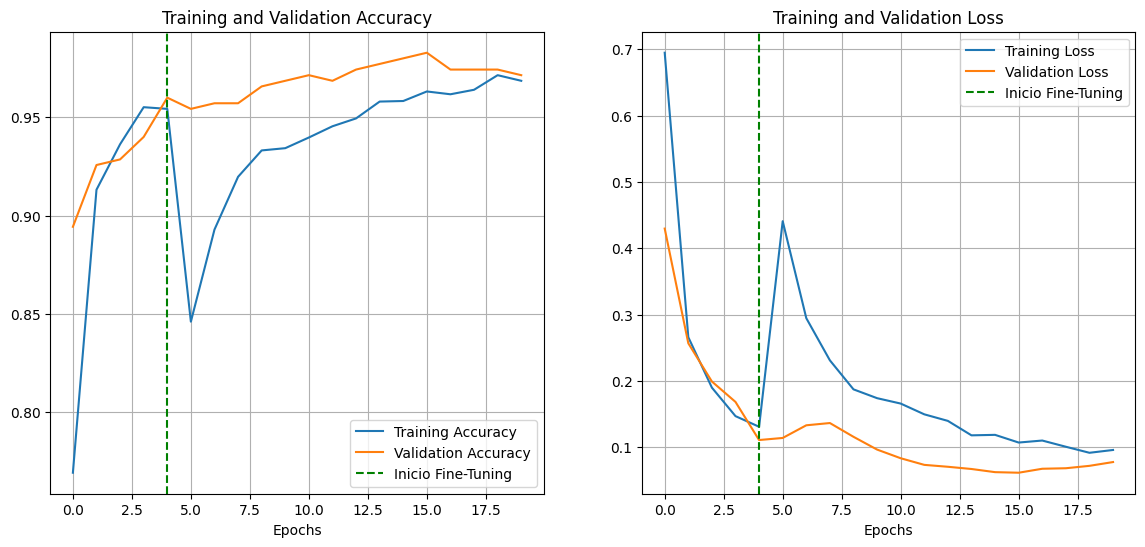

In [12]:
def plot_training_history(h1, h2):
    acc = h1.history['accuracy'] + h2.history['accuracy']
    val_acc = h1.history['val_accuracy'] + h2.history['val_accuracy']
    loss = h1.history['loss'] + h2.history['loss']
    val_loss = h1.history['val_loss'] + h2.history['val_loss']

    epochs_range = range(len(acc))

    plt.figure(figsize=(14, 6))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.axvline(x=len(h1.history['accuracy'])-1, color='green', linestyle='--', label='Inicio Fine-Tuning')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')
    plt.xlabel('Epochs')
    plt.grid(True)

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.axvline(x=len(h1.history['loss'])-1, color='green', linestyle='--', label='Inicio Fine-Tuning')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.xlabel('Epochs')
    plt.grid(True)

    plt.show()

plot_training_history(history_1, history_2)

9. Evaluación del modelo (Cálculo de métricas detalladas)

In [13]:
print("\n🧪 Evaluando modelo en Test Set...")

# Obtener etiquetas verdaderas y predicciones
y_true = []
y_pred_probs = []

# Iterar sobre el dataset de test (sin shuffle)
for images, labels in test_ds:
    y_true.extend(np.argmax(labels.numpy(), axis=1))
    preds = model.predict(images, verbose=0)
    y_pred_probs.extend(preds)

y_true = np.array(y_true)
y_pred_probs = np.array(y_pred_probs)
y_pred = np.argmax(y_pred_probs, axis=1)

# Cálculo de métricas One-vs-All por clase
metrics_list = []

for i, class_name in enumerate(class_names):
    # Crear etiquetas binarias para la clase actual vs resto
    y_true_cls = (y_true == i).astype(int)
    y_pred_cls = (y_pred == i).astype(int)

    # Matriz de confusión binaria
    tn, fp, fn, tp = confusion_matrix(y_true_cls, y_pred_cls).ravel()

    # Métricas
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity / TPR
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0 # TNR
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    fpr = fp / (tn + fp) if (tn + fp) > 0 else 0
    youden = recall + specificity - 1

    # AUC One-vs-Rest
    try:
        auc = roc_auc_score(y_true_cls, y_pred_probs[:, i])
    except ValueError:
        auc = 0.0

    support = tp + fn

    metrics_list.append({
        'Class': class_name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall (Sens)': recall,
        'Specificity': specificity,
        'F1-Score': f1,
        'AUC': auc,
        'Youden Index': youden,
        'FPR': fpr,
        'TP': tp, 'TN': tn, 'FP': fp, 'FN': fn,
        'Support': support
    })

metrics_df = pd.DataFrame(metrics_list)


🧪 Evaluando modelo en Test Set...


10. Matriz de Confusión

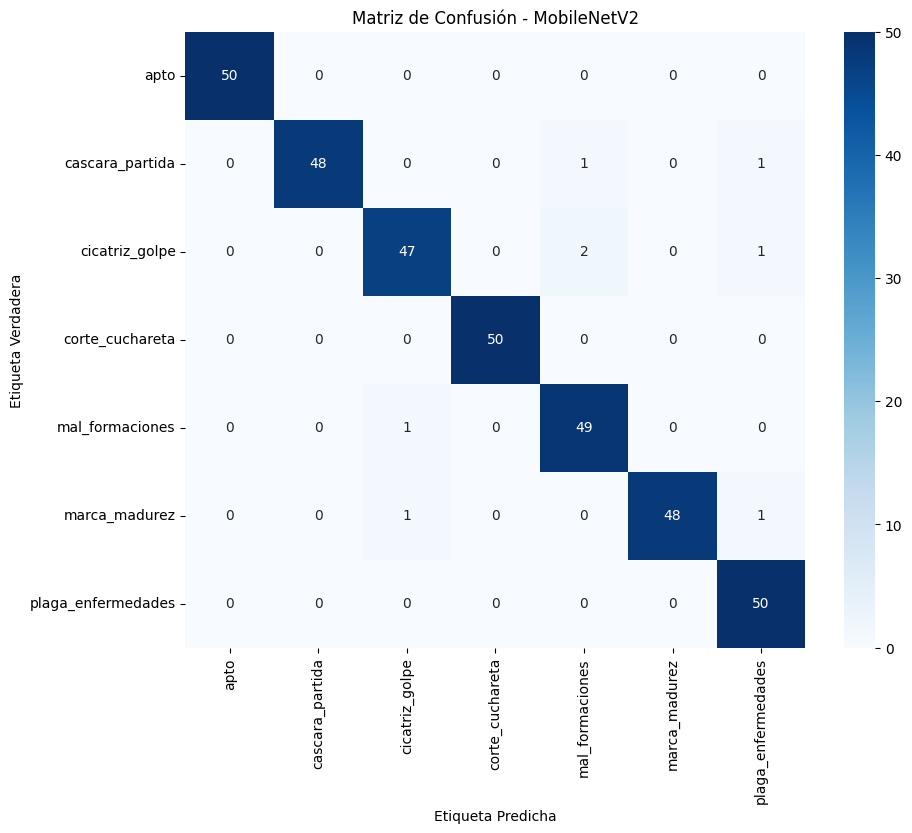

In [14]:
cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.ylabel('Etiqueta Verdadera')
plt.xlabel('Etiqueta Predicha')
plt.title('Matriz de Confusión - MobileNetV2')
plt.show()

11. Tablas de métricas

In [15]:
# 11.1 Tabla por Clase
print("\n📊 Métricas Detalladas por Clase:")
display(metrics_df.round(4))

# 11.2 Métricas Globales (Weighted Average)
global_metrics = {
    'Global Accuracy': accuracy_score(y_true, y_pred),
    'Weighted Precision': precision_score(y_true, y_pred, average='weighted'),
    'Weighted Recall': recall_score(y_true, y_pred, average='weighted'),
    'Weighted F1': f1_score(y_true, y_pred, average='weighted'),
    'Macro Recall': recall_score(y_true, y_pred, average='macro'),
    'Macro AUC': roc_auc_score(y_true, y_pred_probs, multi_class='ovr', average='macro')
}

global_df = pd.DataFrame([global_metrics])
print("\n🌍 Métricas Globales:")
display(global_df.round(4))


📊 Métricas Detalladas por Clase:


,Class,Accuracy,Precision,Recall (Sens),Specificity,F1-Score,AUC,Youden Index,FPR,TP,TN,FP,FN,Support
0,apto,1.0000,1.0000,1.00,1.0000,1.0000,1.0000,1.0000,0.0000,50,300,0,0,50
1,cascara_partida,0.9943,1.0000,0.96,1.0000,0.9796,0.9995,0.9600,0.0000,48,300,0,2,50
2,cicatriz_golpe,0.9857,0.9592,0.94,0.9933,0.9495,0.9983,0.9333,0.0067,47,298,2,3,50
3,corte_cuchareta,1.0000,1.0000,1.00,1.0000,1.0000,1.0000,1.0000,0.0000,50,300,0,0,50
4,mal_formaciones,0.9886,0.9423,0.98,0.9900,0.9608,0.9974,0.9700,0.0100,49,297,3,1,50
5,marca_madurez,0.9943,1.0000,0.96,1.0000,0.9796,0.9999,0.9600,0.0000,48,300,0,2,50
6,plaga_enfermedades,0.9914,0.9434,1.00,0.9900,0.9709,0.9999,0.9900,0.0100,50,297,3,0,50



🌍 Métricas Globales:


,Global Accuracy,Weighted Precision,Weighted Recall,Weighted F1,Macro Recall,Macro AUC
0,0.9771,0.9778,0.9771,0.9772,0.9771,0.9993


12. Evaluación del mejor modelo

In [16]:
print(f"\n🏆 Cargando el mejor modelo guardado desde: {BEST_MODEL_PATH}")
try:
    best_model = tf.keras.models.load_model(BEST_MODEL_PATH)

    # Evaluación rápida del mejor modelo
    loss, acc = best_model.evaluate(test_ds, verbose=0)
    print(f"Best Model Test Accuracy: {acc:.4f}")
    print(f"Best Model Test Loss: {loss:.4f}")

    # Comprobación de selección
    if acc > global_metrics['Global Accuracy']:
        print("✅ El modelo guardado es mejor que el modelo final en memoria.")
    else:
        print("ℹ️ El modelo en memoria tiene un rendimiento similar o igual.")

except Exception as e:
    print(f"Error cargando el modelo: {e}")


🏆 Cargando el mejor modelo guardado desde: /content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2/banano_MobileNetV2_best_scientific.keras
Best Model Test Accuracy: 0.9771
Best Model Test Loss: 0.0748
✅ El modelo guardado es mejor que el modelo final en memoria.


13. Resultados finales y Conclusiones

In [ ]:
# Generar reporte de texto estándar de scikit-learn para complementar
print("\n📝 Classification Report (Scikit-Learn Standard):")
print(classification_report(y_true, y_pred, target_names=class_names))

# Análisis de resultados 
best_class = metrics_df.loc[metrics_df['F1-Score'].idxmax()]
worst_class = metrics_df.loc[metrics_df['F1-Score'].idxmin()]

print("="*50)
print("CONCLUSIONES DEL EXPERIMENTO")
print("="*50)
print(f"1. Rendimiento Global: El modelo alcanzó una exactitud (Top-1 Accuracy) del {global_metrics['Global Accuracy']:.2%}.")
print(f"2. Mejor Clase: '{best_class['Class']}' con un F1-Score de {best_class['F1-Score']:.4f}.")
print(f"3. Peor Clase: '{worst_class['Class']}' con un F1-Score de {worst_class['F1-Score']:.4f}. (Posible confusión visual).")
print(f"4. Discriminación: El AUC promedio es {global_metrics['Macro AUC']:.4f}, indicando una { 'excelente' if global_metrics['Macro AUC'] > 0.9 else 'buena' } capacidad de separación entre clases.")
print(f"5. Tiempos: El entrenamiento total tomó aproximadamente {(phase1_time+phase2_time)/60:.1f} minutos.")
print("="*50)


📝 Classification Report (Scikit-Learn Standard):
                    precision    recall  f1-score   support

              apto       1.00      1.00      1.00        50
   cascara_partida       1.00      0.96      0.98        50
    cicatriz_golpe       0.96      0.94      0.95        50
   corte_cuchareta       1.00      1.00      1.00        50
   mal_formaciones       0.94      0.98      0.96        50
     marca_madurez       1.00      0.96      0.98        50
plaga_enfermedades       0.94      1.00      0.97        50

          accuracy                           0.98       350
         macro avg       0.98      0.98      0.98       350
      weighted avg       0.98      0.98      0.98       350

CONCLUSIONES DEL EXPERIMENTO
1. Rendimiento Global: El modelo alcanzó una exactitud (Top-1 Accuracy) del 97.71%.
2. Mejor Clase: 'apto' con un F1-Score de 1.0000.
3. Peor Clase: 'cicatriz_golpe' con un F1-Score de 0.9495. (Posible confusión visual).
4. Discriminación: El AUC promedio es

14. EXPORTACIÓN DEL MODELO Y ETIQUETAS (DEPLOYMENT)

In [ ]:
import tensorflow as tf
import os

# =========================================================
# 14. EXPORTACIÓN DEL MODELO Y ETIQUETAS (DEPLOYMENT)
# =========================================================

print(f"\n📲 Preparando archivos para despliegue en móvil...")

# ---------------------------------------------------------
# PASO 1: Convertir el modelo .keras a .tflite
# ---------------------------------------------------------
print("1️⃣  Cargando el mejor modelo guardado (.keras)...")

# Verificar que existe el archivo antes de cargar
if not os.path.exists(BEST_MODEL_PATH):
    raise FileNotFoundError(f"❌ No se encontró el modelo en: {BEST_MODEL_PATH}")

model = tf.keras.models.load_model(BEST_MODEL_PATH)

print("2️⃣  Configurando el convertidor TFLite...")
converter = tf.lite.TFLiteConverter.from_keras_model(model)

# Optimizaciones: 'DEFAULT' aplica cuantización dinámica 
converter.optimizations = [tf.lite.Optimize.DEFAULT]

print("3️⃣  Convirtiendo modelo (esto puede tardar unos segundos)...")
tflite_model = converter.convert()

# Definir ruta de salida
tflite_filename = "banano_mobileNetV2.tflite"
tflite_path = os.path.join(MODELS_DIR, tflite_filename)

# Guardar el archivo binario
with open(tflite_path, 'wb') as f:
    f.write(tflite_model)

print(f"✅ Modelo TFLite exportado exitosamente: {tflite_path}")

# ---------------------------------------------------------
# PASO 2: Guardar etiquetas (Labels)
# ---------------------------------------------------------
print("4️⃣  Generando archivo de etiquetas (labels.txt)...")
labels_path = os.path.join(MODELS_DIR, "labels.txt")

with open(labels_path, 'w') as f:
    for name in class_names:
        f.write(name + '\n')

print(f"✅ Etiquetas guardadas en: {labels_path}")

# ---------------------------------------------------------
# Verificación final para el desarrollador
# ---------------------------------------------------------
print("\n" + "="*50)
print("📌 INSTRUCCIONES PARA FLUTTER")
print("="*50)
print("1. Copia el archivo .tflite y labels.txt a la carpeta 'assets/' de tu proyecto Flutter.")
print("2. Asegúrate de que el orden de las clases sea EXACTAMENTE este:")
print("-" * 20)
for i, name in enumerate(class_names):
    print(f"[{i}] -> {name}")
print("-" * 20)


📲 Preparando archivos para despliegue en móvil...
1️⃣  Cargando el mejor modelo guardado (.keras)...
2️⃣  Configurando el convertidor TFLite...
3️⃣  Convirtiendo modelo (esto puede tardar unos segundos)...
Saved artifact at '/tmp/tmptabdrf1g'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='input_layer')
Output Type:
  TensorSpec(shape=(None, 7), dtype=tf.float32, name=None)
Captures:
  133420026907920: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155489552: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155492624: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155491856: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155488400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155491088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155488592: TensorSpec(shape=(), dtype=tf.resource, name=None)
  133420155493392: T

15. Análisis de Optimización: Comparativa de Pesos

📊 Gráfico de comparación guardado en: /content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2/model_size_comparison_efficientnetb0.png


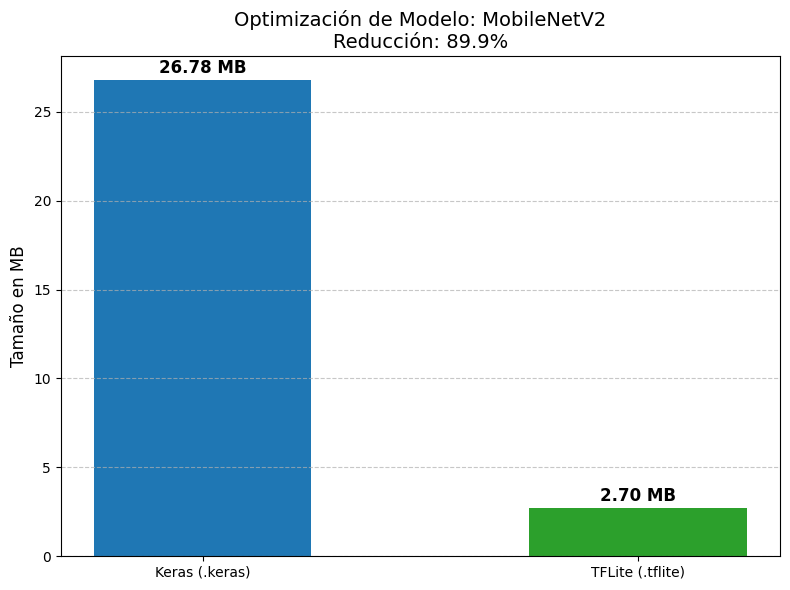

In [ ]:
import matplotlib.pyplot as plt
import os

# Configuración de rutas para guardar la gráfica
img_save_path = "/content/drive/MyDrive/Entrenamiento con balanceo/MobileNetV2"
os.makedirs(img_save_path, exist_ok=True)

# Obtener tamaños de archivo en MB
keras_size = os.path.getsize(BEST_MODEL_PATH) / (1024 * 1024)
tflite_size = os.path.getsize(tflite_path) / (1024 * 1024)

# Datos para el gráfico
models_comparison = ['Keras (.keras)', 'TFLite (.tflite)']
sizes = [keras_size, tflite_size]
colors = ['#1f77b4', '#2ca02c']  # Azul y Verde

# ===== Gráfico de comparación de tamaños =====
plt.figure(figsize=(8, 6))
bars = plt.bar(models_comparison, sizes, color=colors, width=0.5)

plt.ylabel('Tamaño en MB', fontsize=12)
plt.title(f'Optimización de Modelo: MobileNetV2\nReducción: {100 * (1 - tflite_size/keras_size):.1f}%', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Añadir etiquetas de valor sobre las barras
for bar in bars:
    yval = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        yval + 0.2,
        f'{yval:.2f} MB',
        ha='center',
        va='bottom',
        fontsize=12,
        fontweight='bold'
    )

plt.tight_layout()

# Guardar la gráfica
output_chart_path = os.path.join(img_save_path, "model_size_comparison_efficientnetb0.png")
plt.savefig(output_chart_path, dpi=300, bbox_inches='tight')

print(f"📊 Gráfico de comparación guardado en: {output_chart_path}")
plt.show()